In [2]:
# uncomment line 2 if running on a clean kernel
# !pip -q install datasets pandas numpy matplotlib pillow

import os, re, math, random, warnings, textwrap
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from PIL import Image
from IPython.display import display, Markdown

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ppaths
META_CSV = "./metadata.csv"
IMG_DIR  = "./images"
FIG_DIR  = "./visualizations"
CHAP3_DIR = "./chap3_assets"

for d in [IMG_DIR, FIG_DIR, CHAP3_DIR]:
    os.makedirs(d, exist_ok=True)

print("OK: imports + folders ready")

OK: imports + folders ready


Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

Previewing ds['raw'][idx] and its image:


{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x576>,
 'source': 'Ulcerative Colitis',
 'question': 'How many polyps are in the image?',
 'answer': '0',
 'img_id': 'cla820gl0s3o3071ufxqh1brg'}

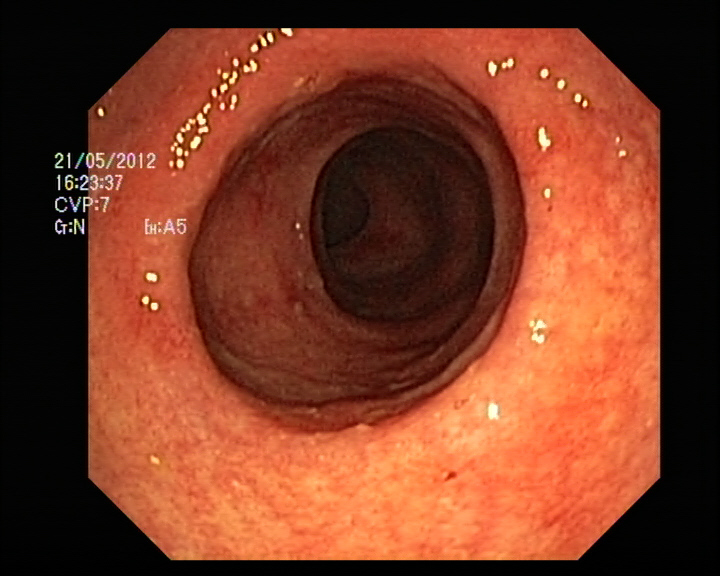

In [3]:
#  load the Hugging Face dataset and preview one record
ds = load_dataset("SimulaMet-HOST/Kvasir-VQA")
idx = 42  # arbitrary, fixed for reproducibility

print("Previewing ds['raw'][idx] and its image:")
display(ds['raw'][idx])
display(ds['raw'][idx]['image'])  # PIL image

In [4]:
#  export ./metadata.csv
df = ds['raw'].select_columns(['source','question','answer','img_id']).to_pandas()
df.to_csv(META_CSV, index=False)
print(f"Saved {len(df):,} QA rows → {META_CSV}")

# quick peek
display(df.head())

Saved 58,849 QA rows → ./metadata.csv


,source,question,answer,img_id
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq
3,Ulcerative Colitis,Have all polyps been removed?,not relevant,cla820gl0s3nv071u4fgd7xgq
4,Ulcerative Colitis,Is this finding easy to detect?,yes,cla820gl0s3nv071u4fgd7xgq


In [6]:
# save one JPEG per unique image id to ./images/
first_row_idx = {}
n_rows = len(ds['raw'])
for i in range(n_rows):
    iid = ds['raw'][i]['img_id']
    if iid not in first_row_idx:
        first_row_idx[iid] = i

expected_imgs = df['img_id'].nunique()
already = {os.path.splitext(f)[0] for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")}
todo = [iid for iid in first_row_idx.keys() if iid not in already]

print(f"Unique images expected: {expected_imgs:,}")
print(f"Images present in {IMG_DIR!s}: {len(already):,}")
print(f"Missing to save: {len(todo):,}")


for k, img_id in enumerate(todo, start=1):
    try:
        pil_im = ds['raw'][first_row_idx[img_id]]['image']
        pil_im.save(os.path.join(IMG_DIR, f"{img_id}.jpg"))
    except Exception as e:
        warnings.warn(f"Could not save {img_id}.jpg: {e}")
    if (k % 500 == 0) or (k == len(todo)):
        print(f"  ...saved {k}/{len(todo)}")

saved_count = len([f for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")])
print(f"Done. Saved images: {saved_count:,} / expected unique: {expected_imgs:,} {'(OK)' if saved_count==expected_imgs else '(NOT COMPLETE)'}")

#  approx  total size
def _dir_size_gb(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            try:
                total += os.path.getsize(fp)
            except OSError:
                pass
    return total / (1024**3)

approx_gb = _dir_size_gb(IMG_DIR)
print(f"Approx image folder size: {approx_gb:.2f} GB (expect ~1.5 GB)")

Unique images expected: 6,500
Images present in ./images: 6,500
Missing to save: 0
Done. Saved images: 6,500 / expected unique: 6,500 (OK)
Approx image folder size: 0.33 GB (expect ~1.5 GB)



=== BASIC FACTS (use in Chapter 3) ===
Total QA pairs: 58,849
Unique images:  6,500


count    6500.000000
mean        9.053692
std         7.017818
min         1.000000
25%         1.000000
50%         9.000000
75%        17.000000
max        18.000000
Name: count, dtype: float64

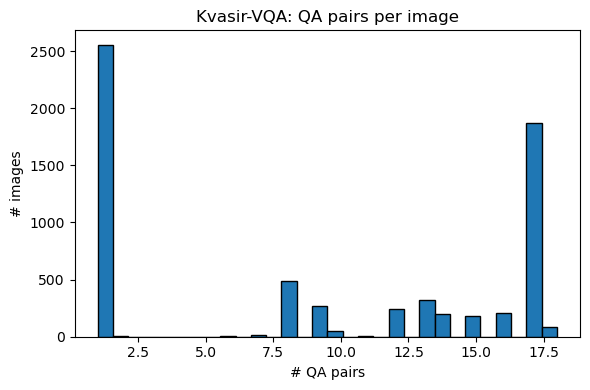

In [7]:

n_qa = len(df)
n_img = df['img_id'].nunique()
qa_per_img = df['img_id'].value_counts()

print("\n=== BASIC FACTS (use in Chapter 3) ===")
print(f"Total QA pairs: {n_qa:,}")
print(f"Unique images:  {n_img:,}")
display(qa_per_img.describe())

plt.figure(figsize=(6,4))
plt.hist(qa_per_img.values, bins=30, edgecolor="black")
plt.title("Kvasir-VQA: QA pairs per image")
plt.xlabel("# QA pairs"); plt.ylabel("# images")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/qa_per_image_hist.png", dpi=200)
plt.show()

source
Ulcerative Colitis    16890
Esophagitis           16723
Polyps                13539
Instrument             9197
Normal                 2500
Name: count, dtype: int64

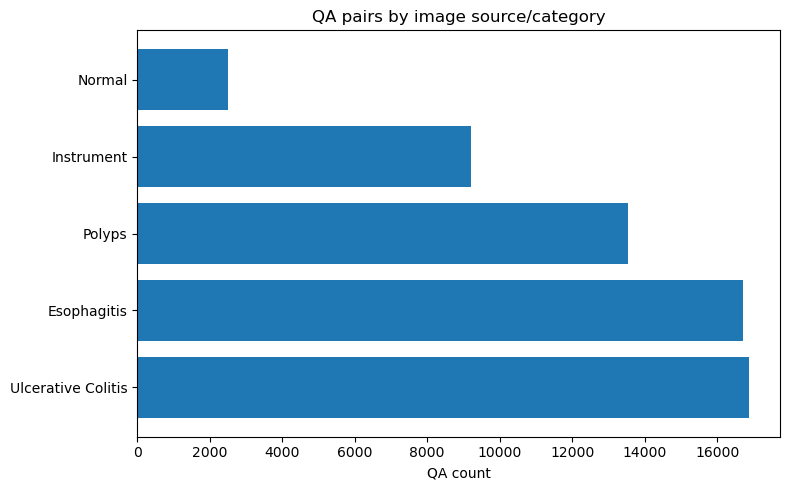

source
Normal                2500
Esophagitis           1000
Instrument            1000
Polyps                1000
Ulcerative Colitis    1000
Name: img_id, dtype: int64

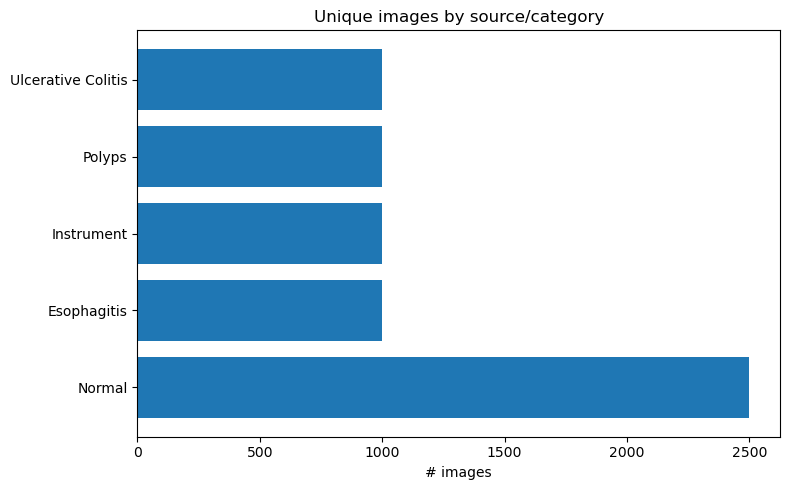

In [8]:

qa_by_source = df['source'].value_counts().sort_values(ascending=False)
display(qa_by_source)
qa_by_source.to_csv(f"{FIG_DIR}/qa_by_source.csv", header=['qa_count'])

plt.figure(figsize=(8,5))
plt.barh(qa_by_source.index.astype(str), qa_by_source.values)
plt.title("QA pairs by image source/category")
plt.xlabel("QA count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/qa_by_source.png", dpi=200)
plt.show()

unique_imgs_by_source = df.groupby('source')['img_id'].nunique().sort_values(ascending=False)
display(unique_imgs_by_source)
unique_imgs_by_source.to_csv(f"{FIG_DIR}/unique_images_by_source.csv", header=['unique_images'])

plt.figure(figsize=(8,5))
plt.barh(unique_imgs_by_source.index.astype(str), unique_imgs_by_source.values)
plt.title("Unique images by source/category")
plt.xlabel("# images")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/unique_images_by_source.png", dpi=200)
plt.show()

question_type
Yes/No      26515
Entity      10528
Counting    10118
Location     8424
Color        3213
Other          51
Name: count, dtype: int64

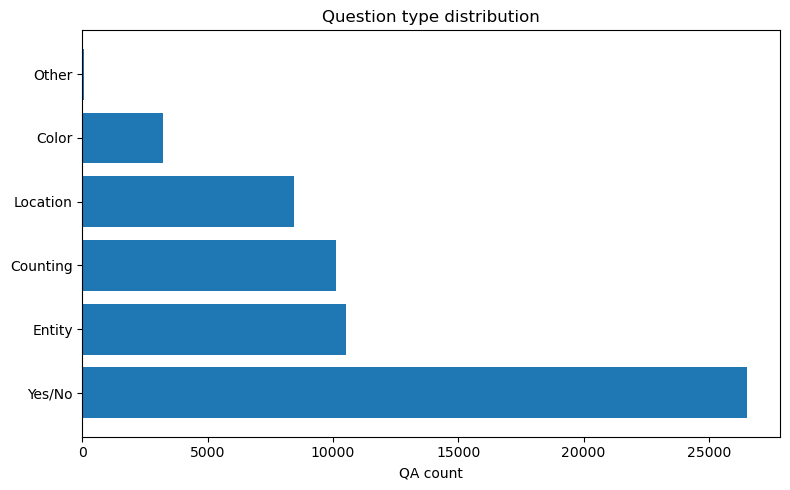

In [9]:

_qtype_regex = [
    ("Counting", re.compile(r"\b(how many|count)\b", re.I)),
    ("Yes/No",   re.compile(r"^(is|are|was|were|does|do|did|can|could|has|have|had)\b", re.I)),
    ("Location", re.compile(r"\b(where|which\s+(region|part|area)|location)\b", re.I)),
    ("Color",    re.compile(r"\b(color|colour)\b", re.I)),
    ("Entity",   re.compile(r"^(what|which)\b", re.I)),
]

def classify_qtype(q: str) -> str:
    s = str(q) if pd.notna(q) else ""
    for label, rgx in _qtype_regex:
        if rgx.search(s):
            return label
    return "Other"

df['question_type'] = df['question'].astype(str).apply(classify_qtype)
qtype_counts = df['question_type'].value_counts()
display(qtype_counts)
qtype_counts.to_csv(f"{FIG_DIR}/question_type_counts.csv", header=['count'])

plt.figure(figsize=(8,5))
plt.barh(qtype_counts.index.astype(str), qtype_counts.values)
plt.title("Question type distribution")
plt.xlabel("QA count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/question_type_distribution.png", dpi=200)
plt.show()

In [10]:
def normalize_q(q: str) -> str:
    s = str(q).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[?!.]+$", "", s)
    return s

df['question_norm'] = df['question'].astype(str).apply(normalize_q)
template_counts = df['question_norm'].value_counts()

print("Top 25 normalized question templates:")
display(template_counts.head(25))

template_counts.head(50).to_csv(f"{FIG_DIR}/top_question_templates.csv", header=['count'])

Top 25 normalized question templates:


question_norm
have all polyps been removed                                                   3945
is this finding easy to detect                                                 3941
is there text                                                                  3941
is there a green/black box artefact                                            3940
what type of procedure is the image taken from                                 3939
how many instrumnets are in the image                                          3555
how many findings are present                                                  3429
what type of polyp is present                                                  3331
what is the size of the polyp                                                  3258
where in the image is the instrument                                           3154
are there any instruments in the image? check all that are present             3148
how many polyps are in the image                              

answer_type
Yes/No     15243
None/NA    13544
Token      12151
Numeric    10118
List        7793
Name: count, dtype: int64

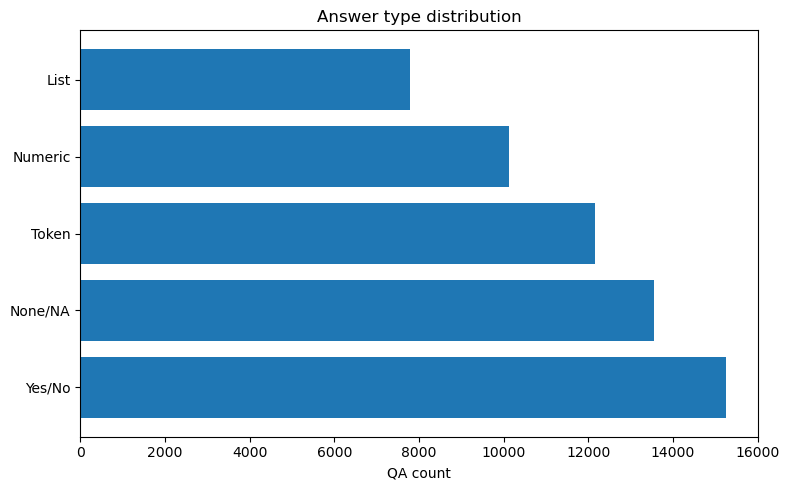

Top 20 specific (non-trivial) answers:


answer
0                                                                                                                  4538
1                                                                                                                  4380
colonoscopy                                                                                                        2944
center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right    1794
pink; red; white                                                                                                   1271
polyp                                                                                                              1137
2                                                                                                                  1116
gastroscopy                                                                                                         993
ulcerative colitis               

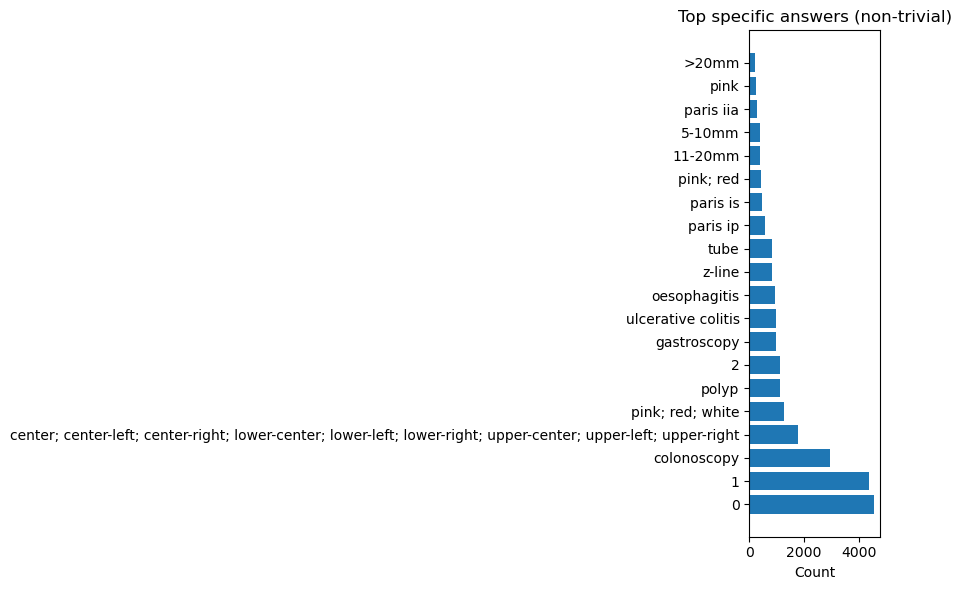

In [11]:
def answer_type(a: str) -> str:
    s = str(a).strip().lower()
    if s in {"yes", "no"}:
        return "Yes/No"
    if s in {"none", "no finding", "not relevant", "not_applicable", "not applicable"}:
        return "None/NA"
    if re.fullmatch(r"\d+", s):
        return "Numeric"
    if ";" in s or "," in s:
        return "List"
    return "Token"

df['answer'] = df['answer'].fillna("")
df['answer_type'] = df['answer'].apply(answer_type)

atype_counts = df['answer_type'].value_counts()
display(atype_counts)
atype_counts.to_csv(f"{FIG_DIR}/answer_type_counts.csv", header=['count'])

plt.figure(figsize=(8,5))
plt.barh(atype_counts.index.astype(str), atype_counts.values)
plt.title("Answer type distribution")
plt.xlabel("QA count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/answer_type_distribution.png", dpi=200)
plt.show()


mask_nontrivial = ~df['answer_type'].isin(["Yes/No", "None/NA"])
top_answers = df.loc[mask_nontrivial, 'answer'].value_counts().head(20)
print("Top 20 specific (non-trivial) answers:")
display(top_answers)
top_answers.to_csv(f"{FIG_DIR}/top_nontrivial_answers.csv", header=['count'])

plt.figure(figsize=(9,6))
plt.barh(top_answers.index.astype(str), top_answers.values)
plt.title("Top specific answers (non-trivial)")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/top_nontrivial_answers.png", dpi=200)
plt.show()

question_type,Color,Counting,Entity,Location,Other,Yes/No
source,,,,,,
Esophagitis,1077,2967,2967,2964,11,6737
Instrument,164,1595,1265,1129,26,5018
Normal,0,0,0,0,0,2500
Polyps,978,2576,3316,1354,8,5307
Ulcerative Colitis,994,2980,2980,2977,6,6953


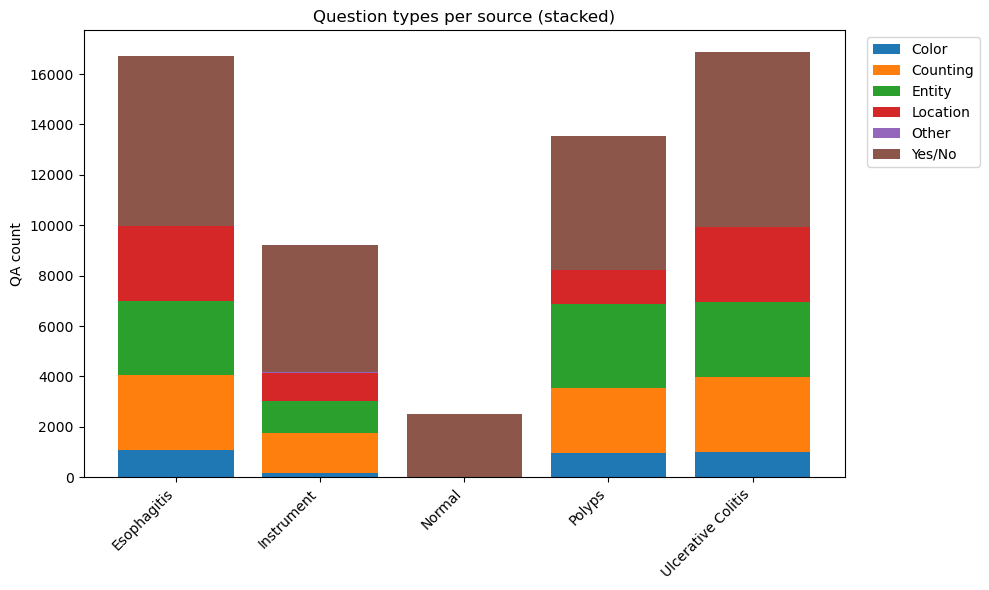

In [12]:
ct = pd.crosstab(df['source'], df['question_type']).sort_index()
display(ct)
ct.to_csv(f"{FIG_DIR}/crosstab_source_qtype.csv")

plt.figure(figsize=(10,6))
bottom = np.zeros(len(ct))
for col in ct.columns:
    vals = ct[col].values
    plt.bar(ct.index.astype(str), vals, bottom=bottom, label=col)
    bottom += vals
plt.title("Question types per source (stacked)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("QA count")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/qtype_per_source_stacked.png", dpi=220)
plt.show()

Colonoscopy subset: 42,126 / 58,849 QA rows (5,500 images)


question_type,Color,Counting,Entity,Location,Other,Yes/No
source,,,,,,
Instrument,164,1595,1265,1129,26,5018
Normal,0,0,0,0,0,2500
Polyps,978,2576,3316,1354,8,5307
Ulcerative Colitis,994,2980,2980,2977,6,6953


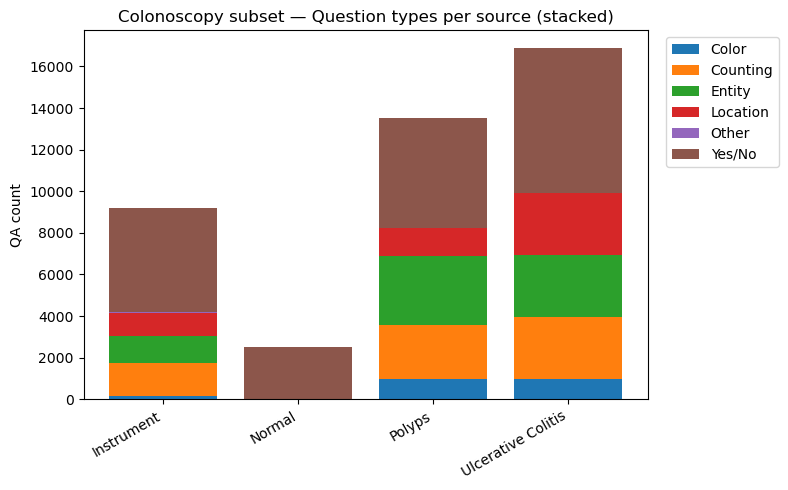

In [13]:

COLONOSCOPY_SOURCES = ["Ulcerative Colitis", "Polyps", "Instrument", "Normal"]

mask_colono = df['source'].isin(COLONOSCOPY_SOURCES)
df_colono = df[mask_colono].copy()

print(f"Colonoscopy subset: {len(df_colono):,} / {len(df):,} QA rows "
      f"({df_colono['img_id'].nunique():,} images)")
df_colono.to_csv("./colonoscopy_metadata.csv", index=False)


ct_colono = pd.crosstab(df_colono['source'], df_colono['question_type']).sort_index()
display(ct_colono)
ct_colono.to_csv(f"{FIG_DIR}/crosstab_colono_source_qtype.csv")

plt.figure(figsize=(8,5))
bottom = np.zeros(len(ct_colono))
for col in ct_colono.columns:
    vals = ct_colono[col].values
    plt.bar(ct_colono.index.astype(str), vals, bottom=bottom, label=col)
    bottom += vals
plt.title("Colonoscopy subset — Question types per source (stacked)")
plt.xticks(rotation=30, ha='right')
plt.ylabel("QA count")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/colono_qtype_per_source_stacked.png", dpi=220)
plt.show()

### Demo view — img_id: `cla820gl0s3nv071u4fgd7xgq`

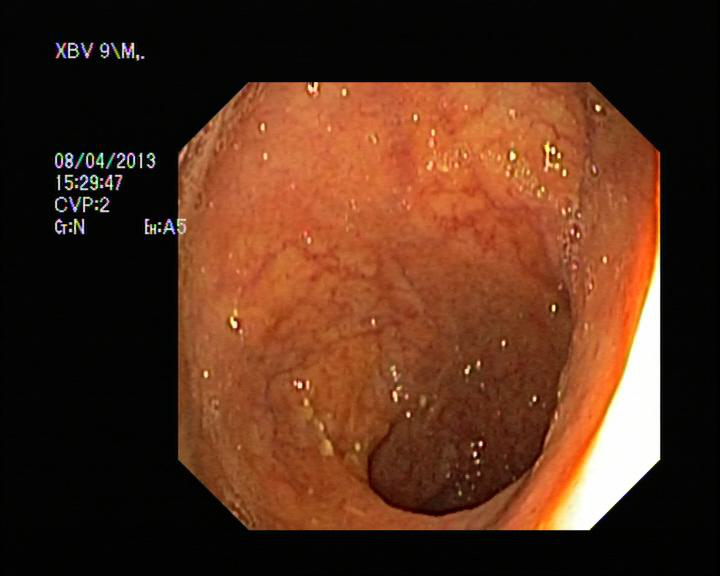

,question,answer
0,Are there any abnormalities in the image? Chec...,ulcerative colitis
1,Are there any anatomical landmarks in the imag...,none
2,Are there any instruments in the image? Check ...,none
3,Have all polyps been removed?,not relevant
4,Is this finding easy to detect?,yes
5,Is there a green/black box artefact?,no


In [14]:
def view_image_and_qas(img_id: str, k: int = 5, subset: pd.DataFrame = None):
    """
    Display a locally saved image and the first k QA pairs for that img_id.
    Avoids reloading Hugging Face; uses ./images/{img_id}.jpg
    """
    subset = df if subset is None else subset
    path = os.path.join(IMG_DIR, f"{img_id}.jpg")
    if not os.path.exists(path):
        print(f"Image not found locally: {path}")
        return
    try:
        im = Image.open(path).convert("RGB")
        display(im)
    except Exception as e:
        print(f"Error opening {path}: {e}")
        return
    rows = subset[subset['img_id'] == img_id][['question','answer']].head(k)
    display(rows)


if not df_colono.empty:
    demo_img_id = df_colono['img_id'].iloc[0]
    display(Markdown(f"### Demo view — img_id: `{demo_img_id}`"))
    view_image_and_qas(demo_img_id, k=6, subset=df_colono)

In [15]:

summary_lines = []

summary_lines.append(f"- **Total QA pairs:** {n_qa:,}")
summary_lines.append(f"- **Unique images:** {n_img:,}")
summary_lines.append(f"- **Median QA per image:** {qa_per_img.median():.0f}")
summary_lines.append(f"- **Images folder size:** ~{_dir_size_gb(IMG_DIR):.2f} GB")
summary_lines.append(f"- **Colonoscopy subset:** {len(df_colono):,} QA over {df_colono['img_id'].nunique():,} images")
summary_lines.append("")
summary_lines.append("**Figures produced**")
for f in sorted(os.listdir(FIG_DIR)):
    if f.lower().endswith((".png",".csv")):
        summary_lines.append(f"  - {os.path.join(FIG_DIR, f)}")

cap_path = os.path.join(CHAP3_DIR, "captions.md")
with open(cap_path, "w", encoding="utf-8") as fh:
    fh.write("# Chapter 3 — Auto-captions & Assets\n\n")
    fh.write("\n".join(summary_lines))
print(f"Wrote captions & checklist → {cap_path}")


display(Markdown(open(cap_path, "r", encoding="utf-8").read()))

Wrote captions & checklist → ./chap3_assets/captions.md


# Chapter 3 — Auto-captions & Assets

- **Total QA pairs:** 58,849
- **Unique images:** 6,500
- **Median QA per image:** 9
- **Images folder size:** ~0.33 GB
- **Colonoscopy subset:** 42,126 QA over 5,500 images

**Figures produced**
  - ./visualizations/answer_type_counts.csv
  - ./visualizations/answer_type_distribution.png
  - ./visualizations/colono_qtype_per_source_stacked.png
  - ./visualizations/crosstab_colono_source_qtype.csv
  - ./visualizations/crosstab_source_qtype.csv
  - ./visualizations/qa_by_source.csv
  - ./visualizations/qa_by_source.png
  - ./visualizations/qa_per_image_hist.png
  - ./visualizations/qtype_per_source_stacked.png
  - ./visualizations/question_type_counts.csv
  - ./visualizations/question_type_distribution.png
  - ./visualizations/top_nontrivial_answers.csv
  - ./visualizations/top_nontrivial_answers.png
  - ./visualizations/top_question_templates.csv
  - ./visualizations/unique_images_by_source.csv
  - ./visualizations/unique_images_by_source.png